# Étape 4 (J4) : Clustering des pays et restitution opérationnelle

Dans cette dernière étape, nous allons :
1. Réaliser une classification non supervisée (**K-Means**) pour regrouper les pays selon leur profil alimentaire et nutritionnel.
2. Déterminer le nombre optimal de clusters ($k$) à l'aide de la méthode du coude (Elbow Method) et du score de silhouette.
3. Interpréter chaque cluster à l'aide de variables descriptives clés et leur attribuer un nom métier.
4. Formuler des recommandations opérationnelles pour la FAO.

## 1.Importation des bibliothèques et préparation des données

In [58]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
%matplotlib inline
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import seaborn as sns

In [59]:
df_global = pd.read_csv('data/dataset_global_fao.csv')
print(df_global.shape)
df_global.head()

(171, 12)


,Zone,Code zone,Kcal_vegetaux,Kcal_animaux,Population_milliers,SousAlimentation_millions,Disponibilite_calorique_totale_kcal,Population_totale,Taux_sousnutrition_pct,Part_animaux_pct,Continent,ISO3
0,Afghanistan,2,1871.0,216.0,30552,7.9,2087.0,30552000,25.857554,10.349784,Asia,AFG
1,Afrique du Sud,202,2533.0,487.0,52776,2.6,3020.0,52776000,4.926482,16.125828,Africa,ZAF
2,Albanie,3,2203.0,985.0,3173,0.2,3188.0,3173000,6.303183,30.897114,Europe,ALB
3,Algérie,4,2915.0,378.0,39208,1.7,3293.0,39208000,4.335850,11.478895,Africa,DZA
4,Allemagne,79,2461.0,1042.0,82727,NaN,3503.0,82727000,NaN,29.745932,Europe,DEU


In [60]:
df = pd.read_csv('data/dataset_global_fao_impute.csv')  
print(df.shape)
df.head(5)

(171, 13)


,Zone,Code zone,Kcal_vegetaux,Kcal_animaux,Population_milliers,SousAlimentation_millions,Disponibilite_calorique_totale_kcal,Population_totale,Taux_sousnutrition_pct,Part_animaux_pct,Continent,ISO3,Part_vegetaux_pct
0,Afghanistan,2,1871.0,216.0,30552,7.9,2087.0,30552000,25.857554,10.349784,Asia,AFG,89.650216
1,Afrique du Sud,202,2533.0,487.0,52776,2.6,3020.0,52776000,4.926482,16.125828,Africa,ZAF,83.874172
2,Albanie,3,2203.0,985.0,3173,0.2,3188.0,3173000,6.303183,30.897114,Europe,ALB,69.102886
3,Algérie,4,2915.0,378.0,39208,1.7,3293.0,39208000,4.335850,11.478895,Africa,DZA,88.521105
4,Angola,7,2221.0,253.0,21472,8.1,2474.0,21472000,37.723547,10.226354,Africa,AGO,89.773646


In [61]:
print(df.columns.tolist())

['Zone', 'Code zone', 'Kcal_vegetaux', 'Kcal_animaux', 'Population_milliers', 'SousAlimentation_millions', 'Disponibilite_calorique_totale_kcal', 'Population_totale', 'Taux_sousnutrition_pct', 'Part_animaux_pct', 'Continent', 'ISO3', 'Part_vegetaux_pct']


In [73]:
df_clustering = df.copy()

# 1. Ajout du guillemet manquant et nettoyage des NaN pour éviter un crash du StandardScaler
X_coude = df_clustering[[
    'Disponibilite_calorique_totale_kcal',
    'Part_vegetaux_pct',
    'Part_animaux_pct',
    'Taux_sousnutrition_pct',
    'Population_totale'
]].dropna()

# 2. Standardisation
scaler = StandardScaler()
X_coude_scaled = scaler.fit_transform(X_coude)

# 3. Affichage du résultat
print(f"Nombre de pays retenus pour le clustering : {X_coude_scaled.shape[0]}")

Nombre de pays retenus pour le clustering : 171


## 2.Détermination de $k$ (Méthode du coude et Score de Silhouette)

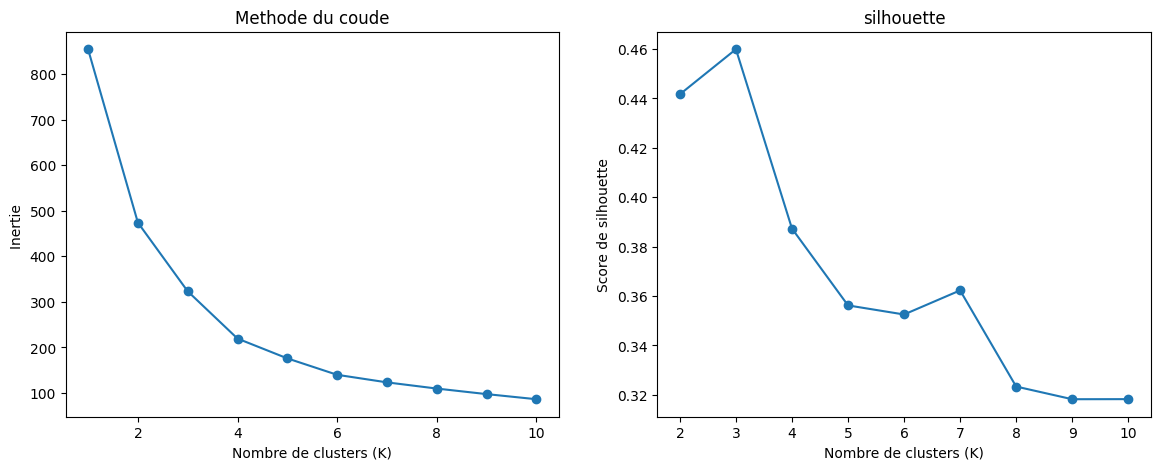

In [75]:
# Test de plusieurs valeurs de k (de 1 à 10)
inerties = []
silhouettes = []
K_range = range(1, 11)

for k in K_range:
  km = KMeans(n_clusters=k, random_state=42, n_init=10)
  labels = km.fit_predict(X_coude_scaled)
  inerties.append(km.inertia_)
  # silhouette_score n'est pas défini pour k=1 (il faut au moins 2 clusters)
  if k >= 2:
    silhouettes.append(silhouette_score(X_coude_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K_range,inerties, marker="o")
axes[0].set_xlabel("Nombre de clusters (K)")
axes[0].set_ylabel("Inertie ")
axes[0].set_title("Methode du coude")

axes[1].plot(list(K_range)[1:],silhouettes, marker="o")
axes[1].set_xlabel("Nombre de clusters (K)")
axes[1].set_ylabel("Score de silhouette")
axes[1].set_title("silhouette")

plt.show()

## 3.Entraînement du modèle K-Means final

In [77]:
n_c = 4
kmeans_final = KMeans(n_clusters=n_c, random_state=42, n_init=10)
df_clustering['Cluster'] = kmeans_final.fit_predict(X_coude_scaled)

print(f"total clusters: {df_clustering['Cluster'].nunique()}")
print(df_clustering['Cluster'].value_counts().sort_index())

total clusters: 4
Cluster
0    66
1    40
2    63
3     2
Name: count, dtype: int64


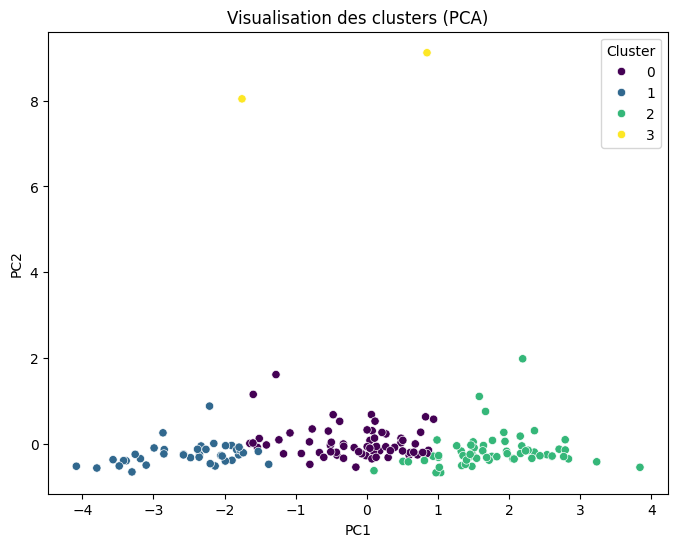

In [78]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_coude_scaled)
df_clustering['PC1'] = X_pca[:, 0]
df_clustering['PC2'] = X_pca[:, 1]

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_clustering, x='PC1', y='PC2', hue='Cluster', palette='viridis')
plt.title("Visualisation des clusters (PCA)")
plt.show()

In [79]:
for c in sorted(df_clustering['Cluster'].unique()):
    print(f"--- Cluster {c} ---")
    print(df_clustering[df_clustering['Cluster'] == c]['Zone'].sample(2, random_state=42).to_string(index=False))
  

--- Cluster 0 ---
 Grenade
Suriname
--- Cluster 1 ---
 Malawi
Lesotho
--- Cluster 2 ---
Uruguay
 Suisse
--- Cluster 3 ---
 Inde
Chine


In [67]:
df_clustering[['Zone','Cluster']].head()

,Zone,Cluster
0,Afghanistan,1
1,Afrique du Sud,0
2,Albanie,3
3,Algérie,0
4,Angola,1


## 4.Interprétation des clusters

In [81]:
cluster_profil = df_clustering.groupby('Cluster')[[
    'Disponibilite_calorique_totale_kcal',
    'Taux_sousnutrition_pct',
    'Part_animaux_pct',
    'Part_vegetaux_pct',
    'Population_milliers',
]].mean().round(1)

cluster_profil['Nb_pays'] = df_clustering['Cluster'].value_counts()
cluster_profil.sort_values('Cluster')

,Disponibilite_calorique_totale_kcal,Taux_sousnutrition_pct,Part_animaux_pct,Part_vegetaux_pct,Population_milliers,Nb_pays
Cluster,,,,,,
0,2870.0,8.9,15.3,84.7,31757.0,66
1,2301.5,27.9,7.8,92.2,19819.8,40
2,3162.2,5.8,28.4,71.6,22853.4,63
3,2783.0,13.5,16.5,83.5,1334403.5,2


In [82]:
df_clustering[df_clustering['Cluster'] == 3][['Zone', 'Population_totale', 'Disponibilite_calorique_totale_kcal', 'Taux_sousnutrition_pct']].sort_values('Population_totale', ascending=False)

,Zone,Population_totale,Disponibilite_calorique_totale_kcal,Taux_sousnutrition_pct
17,Chine,1416667000,3112.0,9.719998
34,Inde,1252140000,2454.0,17.274426


## 5 Interprétation et Profils des Clusters Identifiés :

**Cluster0** : « Pays à situation équilibrée »**

Caractéristiques : Situation intermédiaire correcte avec 2870.0 kcal/j en disponibilité calorique et 8.9% de taux de sous-nutrition. L'alimentation se compose de 15.3% de produits animaux et 84.7% de végétaux. C'est le groupe le plus vaste avec 66 pays.

**Cluster 1**: « Pays en insécurité alimentaire »

Caractéristiques : Disponibilité calorique faible (2301.5 kcal/j) et taux de sous-nutrition élevé (27.9%). L'alimentation est très majoritairement végétale (92.2% de végétaux contre 7.8% de produits animaux). Ce groupe comprend 40 pays.

**Cluster 2** : « Pays en sécurité alimentaire élevée »

Caractéristiques : Disponibilité calorique élevée (3162.2 kcal/j), part animale forte (28.4%) et taux de sous-nutrition faible (5.8%). Ce groupe comprend 63 pays.

**Cluster 3** : « Pays très peuplés, mais très différents en sécurité alimentaire »

Caractéristiques : Ce groupe isole les deux méga-pays de la planète en raison de leur population colossale (moyenne supérieure à 1,33 milliard d'habitants). Ce groupe compte 2 pays, leurs profils alimentaires sont contrastés :
    Chine : 1,42 milliard d'habitants, 3112.0 kcal/j et 9.7% de sous-nutrition.
    Inde : 1,25 milliard d'habitants, 2454.0 kcal/j et 17.3% de sous-nutrition.


## 6 Restitution et Recommandations Opérationnelles pour la FAO

À l'issue de cette analyse globale et du clustering des profils alimentaires mondiaux (K=4), trois recommandations sont formulées à destination de la FAO :

**1. Concentrer l'aide d'urgence sur les pays en insécurité alimentaire (Cluster 1)**
Les pays de ce groupe cumulent les signaux les plus graves : la plus faible disponibilité calorique de tout l'échantillon (2301.5 kcal/j) et le taux de sous-nutrition le plus élevé (27.9%), avec une alimentation presque entièrement végétale (7.8% de produits animaux).

C'est ce groupe de 40 pays qui doit constituer la priorité absolue pour les programmes d'aide alimentaire d'urgence de la FAO.

**2. Prévenir les risques de surconsommation dans les pays en sécurité alimentaire élevée (Cluster 2)**
À l'inverse, les pays de ce groupe possèdent la disponibilité calorique la plus haute (3162.2 kcal/j), la part de protéines animales la plus forte (28.4%), et un taux de sous-nutrition faible (5.8%).

Pour ces 63 pays, le défi n'est plus la sous-alimentation mais les risques liés à l'excès : la FAO pourrait y orienter ses actions vers l'éducation nutritionnelle, la qualité des régimes et la prévention des maladies métaboliques.

**3. Traiter les géants démographiques (Cluster 3) de manière individualisée**
Le Cluster 3 regroupe des méga-pays en raison de leur population colossale (comme la Chine et l'Inde), mais ce regroupement repose principalement sur l'effet de taille démographique plutôt que sur un profil nutritionnel strictement homogène (avec des taux de sous-nutrition allant par exemple de 9.7% en Chine à 17.3% en Inde).

Plutôt qu'une politique globale pour ce groupe de 2 pays, la FAO doit adapter les interventions aux réalités internes de chacun et suivre ces grands bassins de population séparément pour éviter que leur poids démographique ne fausse les analyses statistiques globales.